# CNN Multi Dim Analysis

## 20251128_172209

### Imports

In [2]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.foldingnet import AutoEncoder
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *

import torch

ModuleNotFoundError: No module named 'biobox'

### Loading Datasets

In [ ]:
atoms = ["N", "CA", "C", "O", 'CB']
mean = json.load(open("data_statistics.json"))["mean"]
std = json.load(open("data_statistics.json"))["std"]

data_closed = PDBData(
    filename=["./data/MurD_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["./data/MurD_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["./data/MurD_closed_apo.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_test.prepare_dataset(mean=mean, std=std)

### Loading the results

In [1]:
log_dfs = {}
min_valid_losses = {}
min_valid_mse_losses = {}
converged_checkpoints = {}

base_path = r"../results/20251128_172209/cnn_multi_dim"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for n in range(2, 11):

    log_dfs[n] = pd.read_csv(Path(f"{base_path}/{n}/log.dat"))
    best_epoch = log_dfs[n]['valid_loss'].idxmin()
    min_valid_losses[n] = min(log_dfs[n].valid_loss)
    min_valid_mse_losses[n] = min(log_dfs[n].valid_mse_loss)

    checkpoint_path = Path(f"{base_path}/{n}/checkpoint_converged.ckpt")
    converged_checkpoints[n] = torch.load(checkpoint_path, map_location=device, weights_only=False)

NameError: name 'torch' is not defined

### MSE Plots 

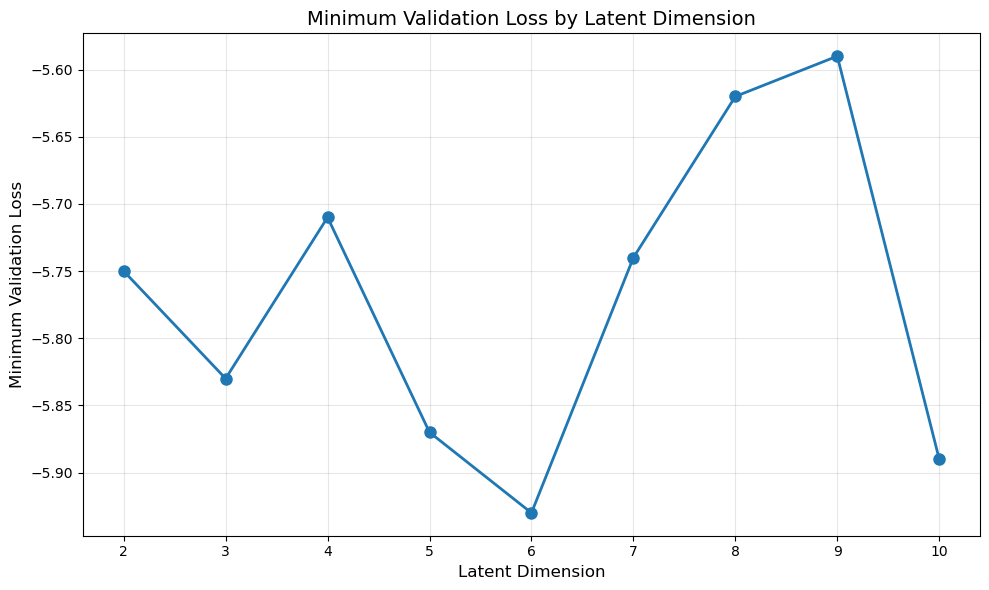

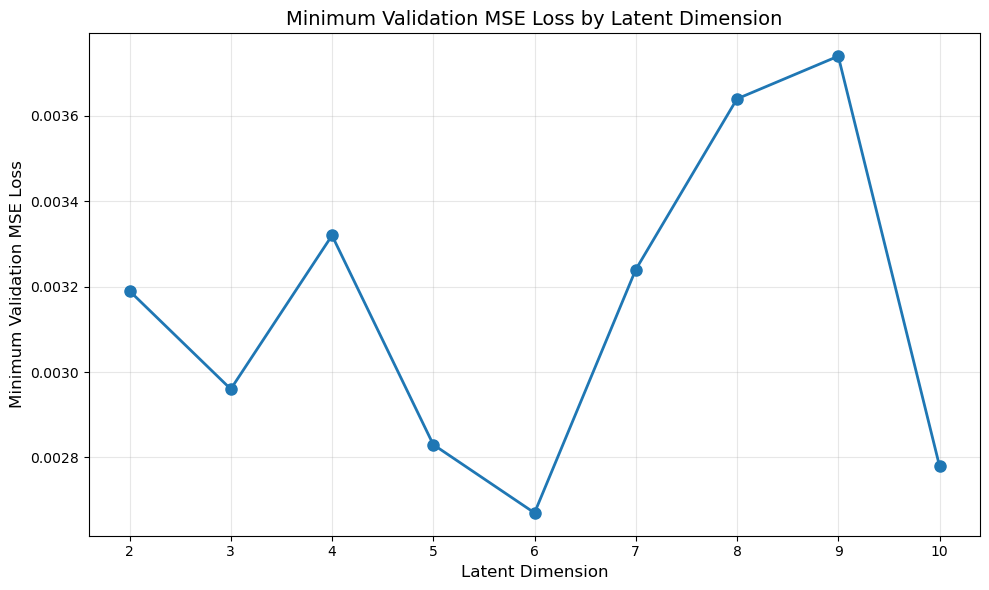

In [24]:
# Plot line graph of minimum validation losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_losses.keys()), list(min_valid_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot line graph of minimum validation MSE_losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_mse_losses.keys()), list(min_valid_mse_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation MSE Loss', fontsize=12)
plt.title('Minimum Validation MSE Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Model plots